# Module 7 Practical Exercises

This practical's notes contain the instruction of deep neural networks and recurrent neural networks using the Pytorch machine learning framework.

For deep neural networks, we will reuse the Veteran dataset from previous practicals, and compare the performance of a deep network with the single hidden layer network.

For recurrent neural networks, we will utilize long short-term memory cells to predict the maximum temperature for the next multiple timestep in various locations of Australia, given the observations from the last few days.

## Preparing Data
---

Use the same code from previous module to load/pre-process the Veteran dataset, and split it into the training/testing set.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# read the veteran dataset
df = pd.read_csv('veteran.csv')

# Change DemCluster from interval/integer to nominal/str.
# Pandas returns a copy of the data whenever you access a column, therefore we need to store it back to the original column.
#print(df['DemCluster'])
df['DemCluster'] = df['DemCluster'].astype(str)

# Change DemHomeOwner into binary 0/1 variable.
dem_home_owner_map = {'U':0, 'H': 1}
df['DemHomeOwner'] = df['DemHomeOwner'].map(dem_home_owner_map)

# Set DemMedIncome to NaN for any values that are less than 1, which we will fix up below.
mask = df['DemMedIncome'] < 1
df.loc[mask, 'DemMedIncome'] = np.nan

# Fill missing/NaN values with the mean value across the columns.
df['DemAge'] = df['DemAge'].fillna(df['DemAge'].mean())
df['DemMedIncome'] = df['DemMedIncome'].fillna(df['DemMedIncome'].mean())
df['GiftAvgCard36'] = df['GiftAvgCard36'].fillna(df['GiftAvgCard36'].mean())

# drop ID and the unused target variable
df.drop(['ID', 'TargetD'], axis=1, inplace=True)

# one-hot encoding
df = pd.get_dummies(df)

# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
Y = df["TargetB"]

# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
X = df.drop(['TargetB'], axis=1)

# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
random_state = 10
test_set_size = 0.3 # 30%
X_train, X_test, y_train, y_test = train_test_split(X.values, Y.values, test_size=test_set_size, stratify=Y, random_state=random_state)

print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

random_seed = 10

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

Size of training set: 6780
Size of testing set: 2906


## Deep Neural Networks
---

The first task of this practical exercise is to extend the multi-layer perceptron neural network to a greater number of layers, creating a deep neural deep network. The "deep" aspect refers to having many hidden layers between input and output, allowing these systems to automatically discover intricate relationships within data without explicit programming of rules.

You will need Pytorch installed and configured for this practical, refer to previous modules for instructions on how to install Pytorch.

First, we will convert the training and test datasets into `torch.tensor`, making them compatible with Pytorch.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
 
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

Next, we will define the network itself.

Pytorch contains the `Sequential` class, which provides a simplified way to build neural networks by arranging layers in a linear sequence, where the output of one layer serves as the input to the next. This container allows developers to define a network's architecture as an ordered list of modules that are automatically connected in sequence, eliminating the need to manually specify how data flows between components.

In [3]:
num_features = X_train.shape[1]
hidden_layer_size = 25
output_size = 1
n_epochs = 100
lr = 0.001
# define the model
model = nn.Sequential(
    nn.Linear(num_features, hidden_layer_size),
    nn.Linear(hidden_layer_size, output_size),
    nn.Sigmoid()
)
print(model)

Sequential(
  (0): Linear(in_features=85, out_features=25, bias=True)
  (1): Linear(in_features=25, out_features=1, bias=True)
  (2): Sigmoid()
)


You will notice that we are explicitly passing the data from one layer to the next, after applying the activation function. The `first` layer is followed by the ReLU activation function, followed by the `second` layer, which maps the hidden layer to the output size, which in this case is a single numerical value.

For our deep neural network, we will use the `Sequential` class. The straightforward syntax makes it particularly useful for quickly prototyping linear network structures, though more complex architectures with branching or skip connections would require custom Module implementations instead.

Let's start by defining a deep network with 5 hidden layers. Each of these hidden layers is represented by a `Linear` class in Pytorch, and we apply the ReLU activation function after each of them. We will use the same size for each of the hidden layers, but this is not required.

In [4]:
num_features = X_train.shape[1]
print(num_features)
hidden_layer_size = 25
output_size = 1      
in_features = num_features
# define the deep model
deep_model = nn.Sequential(
            nn.Linear(in_features, hidden_layer_size), # Input layer -> First Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, hidden_layer_size), # First Hidden Layer -> Second Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, hidden_layer_size), # Second Hidden Layer -> Third Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, hidden_layer_size), # Third Hidden Layer -> Fourth Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, output_size), # Fourth Hidden Layer -> Output Layer
            nn.Sigmoid() # Activation Function
)
print(deep_model)

85
Sequential(
  (0): Linear(in_features=85, out_features=25, bias=True)
  (1): ReLU()
  (2): Linear(in_features=25, out_features=25, bias=True)
  (3): ReLU()
  (4): Linear(in_features=25, out_features=25, bias=True)
  (5): ReLU()
  (6): Linear(in_features=25, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
  (9): Sigmoid()
)


Now we can train and evaluate both networks by passing them into `train_predict_model` function.

In [5]:
def train_predict_model(model, n_epochs, lr, X_train, y_train, X_test, y_test):
    # train the model
    loss_fn   = nn.BCELoss()  # binary cross entropy
    optimizer = optim.Adam(model.parameters(), lr=lr)
    count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"The model has {count:,} trainable parameters")
    
    train_acc_history = []
    test_acc_history = []
    for i in range(n_epochs):
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 
        with torch.no_grad():
            train_pred = model(X_train)
            train_pred = (train_pred >= 0.5).float()
            train_acc = accuracy_score(y_train, train_pred)
            test_pred = model(X_test)
            test_pred = (test_pred >= 0.5).float()
            test_acc = accuracy_score(y_test, test_pred)
        if (i % 1) == 0:
            print(f"Epoch {i+1}: Train Accuracy: {train_acc} Test Accuracy: {test_acc}")
        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)
    return train_acc_history, test_acc_history

In [6]:
model_train_acc, model_test_acc = train_predict_model(model, n_epochs, lr,X_train, y_train, X_test, y_test)
deep_model_train_acc, deep_model_test_acc = train_predict_model(deep_model, n_epochs, lr,X_train, y_train, X_test, y_test)

The model has 2,176 trainable parameters
Epoch 1: Train Accuracy: 0.4957227138643068 Test Accuracy: 0.5017205781142464
Epoch 2: Train Accuracy: 0.4989675516224189 Test Accuracy: 0.5044735030970406
Epoch 3: Train Accuracy: 0.5089970501474926 Test Accuracy: 0.5096352374397798
Epoch 4: Train Accuracy: 0.516519174041298 Test Accuracy: 0.5151410874053682
Epoch 5: Train Accuracy: 0.5228613569321534 Test Accuracy: 0.5178940123881625
Epoch 6: Train Accuracy: 0.5312684365781711 Test Accuracy: 0.522367515485203
Epoch 7: Train Accuracy: 0.5339233038348082 Test Accuracy: 0.5251204404679972
Epoch 8: Train Accuracy: 0.5383480825958702 Test Accuracy: 0.5282174810736407
Epoch 9: Train Accuracy: 0.541740412979351 Test Accuracy: 0.5323468685478321
Epoch 10: Train Accuracy: 0.5451327433628319 Test Accuracy: 0.5388850653819683
Epoch 11: Train Accuracy: 0.5486725663716814 Test Accuracy: 0.5426703372333104
Epoch 12: Train Accuracy: 0.5536873156342182 Test Accuracy: 0.5440467997247075
Epoch 13: Train Accurac

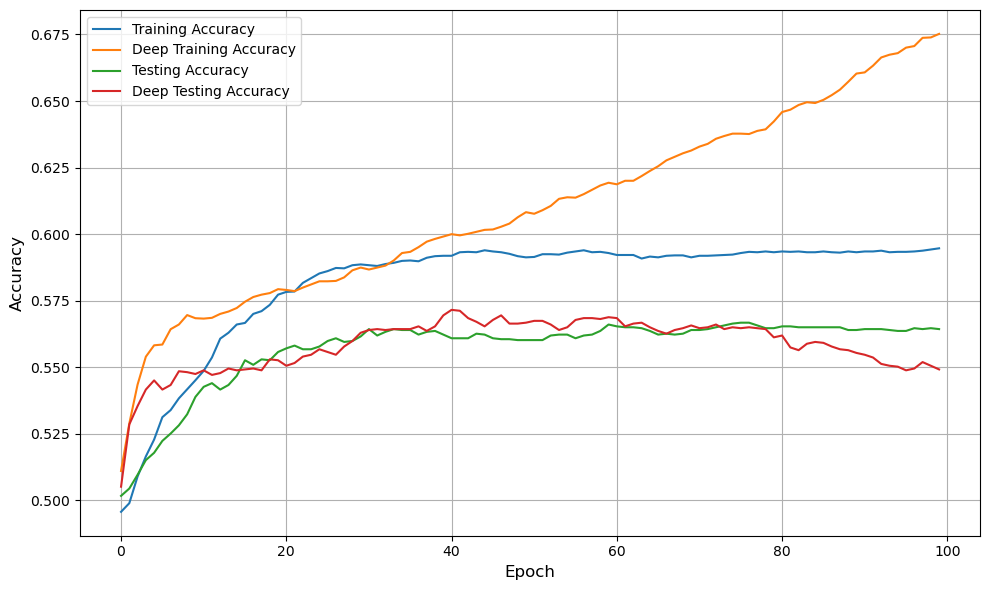

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.xlabel("Epoch", size=12)
plt.ylabel("Accuracy", size=12)
plt.plot(model_train_acc, label="Training Accuracy")
plt.plot(deep_model_train_acc, label="Deep Training Accuracy")
plt.plot(model_test_acc, label="Testing Accuracy")
plt.plot(deep_model_test_acc, label="Deep Testing Accuracy")
plt.grid()
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Comparing the parameter count, we can see that the shallow network has `~4,300` trainable parameters, whereas the deep network has `~12,000`. This suggests that the deep network has significantly more capacity for learning, which also risks overfitting.

We can see this overfitting by examining the plot above: the deep network achieved a much greater training accuracy of almost 90% after 100 epochs, compared to the shallow network which only reached ~65% accuracy after the same amount of time. However, this resulted in overfitting after around epoch #30, with the training accuracy continuing to increase, but the testing accuracy starting to drop.

Therefore, if we were deploying this model, we would want to cease training the network after around 30 epochs. Using early stopping would be one method for automatically stopping training after a number of consecutive epochs resulted in reduced testing accuracy, and roll back to the last "good" set of weights.

We can also observe that the deep network achieved slightly higher testing accuracy at its peak compared to the shallow network. At epoch #39, the accuracy of the deep network was around 56-57%, while the shallow network was 55-56%.

## Recurrent Neural Networks
---

In this module, we introduced the concept of recurrent nerual networks. Specifically, we introduced the long short-term memory (LSTM) neural network, which we will be demonstrating in this practical session.

Long Short-Term Memory (LSTM) networks are a specialized form of recurrent neural networks designed to overcome the vanishing gradient problem that hampers learning in traditional RNNs. By utilizing a gating mechanism that consists of input, forget and output gates, LSTMs can selectively remember or discard information, allowing them to capture long-range dependencies in sequential data. Each LSTM cell maintains a cell state that acts as a conveyor belt of information flowing through the sequence, with gates controlling what information is added, removed, or passed to the output.

LSTMs have a range of applications, including natural language processing, speech recognition, time series prediction, and any domain where contextual information across varying time scales is crucial for accurate predictions. In this practical, we will be exploring time series prediction using LSTMs. While the implementation details for other applications will differ, the high-level approach is the same.

### Dataset for our LSTM network

In this practical, we will use a subset of Australian weather data that contains observations from many locations across Australia, including the minimum/maximum temperature, rainfall, wind, humidity, and pressure. The dataset was preprocessed and contains ~10,000 rows from different cities, and the following columns:

- Location - Name of the city from Australia.
- MinTemp - The Minimum temperature during a particular day. (degree Celsius)
- MaxTemp - The maximum temperature during a particular day. (degree Celsius)
- Rainfall - Rainfall during a particular day. (millimeters)
- WindGuSpeed - Speed of strongest gust during a particular day. (kilometers per hour)
- WindSpeed9am - Speed of the wind for 10 min prior to 9 am. (kilometers per hour)
- WindSpeed3pm - Speed of the wind for 10 min prior to 3 pm. (kilometers per hour)
- Humidity9am - The humidity of the wind at 9 am. (percent)
- Humidity3pm - The humidity of the wind at 3 pm. (percent)
- Pressure9am - Atmospheric pressure at 9 am. (hectopascals)
- Pressure3pm - Atmospheric pressure at 3 pm. (hectopascals)
- Temp9am - The temperature at 9 am. (degree Celsius)
- Temp3pm - The temperature at 3 pm. (degree Celsius)

This raw dataset and information was obtained from Kaggle: https://www.kaggle.com/datasets/arunavakrchakraborty/australia-weather-data

The observations in the dataset itself were sourced from the Bureau of Meteorology, and collated by Arunava Kr. Chakraborty.

In [8]:
df = pd.read_csv("weather.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99516 entries, 0 to 99515
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         99516 non-null  object 
 1   Location       99516 non-null  object 
 2   MinTemp        99073 non-null  float64
 3   MaxTemp        99286 non-null  float64
 4   Rainfall       98537 non-null  float64
 5   Evaporation    56985 non-null  float64
 6   Sunshine       52199 non-null  float64
 7   WindGustDir    92995 non-null  object 
 8   WindGustSpeed  93036 non-null  float64
 9   WindDir9am     92510 non-null  object 
 10  WindDir3pm     96868 non-null  object 
 11  WindSpeed9am   98581 non-null  float64
 12  WindSpeed3pm   97681 non-null  float64
 13  Humidity9am    98283 non-null  float64
 14  Humidity3pm    97010 non-null  float64
 15  Pressure9am    89768 non-null  float64
 16  Pressure3pm    89780 non-null  float64
 17  Cloud9am       61944 non-null  float64
 18  Cloud3

In [9]:
df.drop(columns=['Evaporation', 'Sunshine','Cloud9am', 'Cloud3pm','RainTomorrow'], inplace=True)
# Remove invalid rows.
df = df.dropna()
df

,row ID,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday
0,Row0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No
1,Row1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No
2,Row2,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No
3,Row3,Albury,14.6,29.7,0.2,WNW,56.0,W,W,19.0,24.0,55.0,23.0,1009.2,1005.4,20.6,28.9,No
4,Row4,Albury,7.7,26.7,0.0,W,35.0,SSE,W,6.0,17.0,48.0,19.0,1013.4,1010.1,16.3,25.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99511,Row101816,Uluru,8.0,20.7,0.0,ESE,41.0,SE,E,19.0,26.0,56.0,32.0,1028.1,1024.3,11.6,20.0,No
99512,Row101817,Uluru,3.5,21.8,0.0,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,9.4,20.9,No
99513,Row101818,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,No
99514,Row101819,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,No


In [10]:
# Sort for consistent grouping
samples_sorted = df.sort_values(['Location']).copy()

# Create a 10-day group id per location
samples_sorted['day_index'] = samples_sorted.groupby('Location').cumcount()
samples_sorted['ten_day_group'] = samples_sorted['day_index'] // 20

# Group by Location and 10-day group and take the mean of numeric columns
ten_day_avg = samples_sorted.groupby(['Location', 'ten_day_group']).mean(numeric_only=True).reset_index()

# Optional: drop intermediate columns
ten_day_avg = ten_day_avg.drop(columns=['day_index', 'ten_day_group'], errors='ignore')

# Preview
print(ten_day_avg.head())

   Location  MinTemp  MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  \
0  Adelaide    7.950   17.465      0.95          36.05         10.30   
1  Adelaide    9.185   19.105      1.50          36.85         11.30   
2  Adelaide   10.455   21.415      0.56          37.85         13.75   
3  Adelaide   11.070   20.670      2.98          34.25         10.70   
4  Adelaide   10.935   18.565      2.56          38.30         11.80   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Temp9am  \
0         14.85        57.80        45.65     1027.635     1025.565   12.810   
1         16.65        63.40        50.15     1021.140     1019.075   14.045   
2         16.45        51.00        39.10     1022.005     1018.895   16.235   
3         14.75        66.15        48.95     1019.935     1017.735   15.540   
4         16.65        73.05        55.60     1019.805     1017.770   14.210   

   Temp3pm  
0   16.350  
1   17.705  
2   20.335  
3   19.835  
4   17.730  


In [11]:
ten_day_avg

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,Adelaide,7.950,17.465,0.95,36.05,10.30,14.85,57.80,45.65,1027.635,1025.565,12.810,16.350
1,Adelaide,9.185,19.105,1.50,36.85,11.30,16.65,63.40,50.15,1021.140,1019.075,14.045,17.705
2,Adelaide,10.455,21.415,0.56,37.85,13.75,16.45,51.00,39.10,1022.005,1018.895,16.235,20.335
3,Adelaide,11.070,20.670,2.98,34.25,10.70,14.75,66.15,48.95,1019.935,1017.735,15.540,19.835
4,Adelaide,10.935,18.565,2.56,38.30,11.80,16.65,73.05,55.60,1019.805,1017.770,14.210,17.730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3972,Woomera,19.465,32.030,2.06,48.40,22.25,23.65,58.50,32.05,1011.470,1009.600,22.725,30.235
3973,Woomera,18.540,31.580,2.03,57.20,24.50,25.45,47.10,26.25,1010.665,1008.545,22.605,29.430
3974,Woomera,11.115,24.545,0.71,47.45,23.90,23.40,51.00,25.85,1017.350,1014.740,16.215,23.095
3975,Woomera,14.650,29.455,0.13,47.40,22.35,23.15,43.50,26.95,1018.290,1015.260,20.445,27.890


In [12]:
ten_day_avg['Location'].unique().tolist()

['Adelaide',
 'Albury',
 'AliceSprings',
 'BadgerysCreek',
 'Ballarat',
 'Bendigo',
 'Brisbane',
 'Cairns',
 'Canberra',
 'Cobar',
 'CoffsHarbour',
 'Dartmoor',
 'Darwin',
 'GoldCoast',
 'Hobart',
 'Katherine',
 'Launceston',
 'Melbourne',
 'MelbourneAirport',
 'Mildura',
 'Moree',
 'MountGambier',
 'Nhil',
 'NorahHead',
 'NorfolkIsland',
 'Nuriootpa',
 'PearceRAAF',
 'Perth',
 'PerthAirport',
 'Portland',
 'Richmond',
 'Sale',
 'Sydney',
 'SydneyAirport',
 'Townsville',
 'Tuggeranong',
 'Uluru',
 'WaggaWagga',
 'Walpole',
 'Watsonia',
 'Williamtown',
 'Witchcliffe',
 'Wollongong',
 'Woomera']

In [13]:
ten_day_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3977 entries, 0 to 3976
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       3977 non-null   object 
 1   MinTemp        3977 non-null   float64
 2   MaxTemp        3977 non-null   float64
 3   Rainfall       3977 non-null   float64
 4   WindGustSpeed  3977 non-null   float64
 5   WindSpeed9am   3977 non-null   float64
 6   WindSpeed3pm   3977 non-null   float64
 7   Humidity9am    3977 non-null   float64
 8   Humidity3pm    3977 non-null   float64
 9   Pressure9am    3977 non-null   float64
 10  Pressure3pm    3977 non-null   float64
 11  Temp9am        3977 non-null   float64
 12  Temp3pm        3977 non-null   float64
dtypes: float64(12), object(1)
memory usage: 404.0+ KB


In [14]:
import pandas as pd

# Step 1: Count the number of time steps per location
location_counts = ten_day_avg['Location'].value_counts()

# Step 2: Identify locations with at least 141 time steps
valid_locations = location_counts[location_counts >= 64].index

# Step 3: Filter to keep only valid locations
df_valid = ten_day_avg[ten_day_avg['Location'].isin(valid_locations)].copy()

# Step 4: Trim each location to the first 141 rows
df_trimmed = (
    df_valid.groupby('Location', group_keys=False)
    .apply(lambda x: x.iloc[:64])
    .reset_index(drop=True)
)

# Optional: Confirm result
print(df_trimmed['Location'].value_counts())
print("Total locations kept:", df_trimmed['Location'].nunique())


Location
Adelaide            64
Albury              64
AliceSprings        64
BadgerysCreek       64
Ballarat            64
Bendigo             64
Brisbane            64
Cairns              64
Canberra            64
Cobar               64
CoffsHarbour        64
Dartmoor            64
Darwin              64
GoldCoast           64
Hobart              64
Melbourne           64
MelbourneAirport    64
Mildura             64
Moree               64
MountGambier        64
NorahHead           64
NorfolkIsland       64
Nuriootpa           64
PearceRAAF          64
Perth               64
PerthAirport        64
Portland            64
Richmond            64
Sale                64
Sydney              64
SydneyAirport       64
Townsville          64
Tuggeranong         64
WaggaWagga          64
Walpole             64
Watsonia            64
Williamtown         64
Witchcliffe         64
Wollongong          64
Woomera             64
Name: count, dtype: int64
Total locations kept: 40


/tmp/ipykernel_1675490/733456846.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[:64])


In [15]:
df_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2560 non-null   object 
 1   MinTemp        2560 non-null   float64
 2   MaxTemp        2560 non-null   float64
 3   Rainfall       2560 non-null   float64
 4   WindGustSpeed  2560 non-null   float64
 5   WindSpeed9am   2560 non-null   float64
 6   WindSpeed3pm   2560 non-null   float64
 7   Humidity9am    2560 non-null   float64
 8   Humidity3pm    2560 non-null   float64
 9   Pressure9am    2560 non-null   float64
 10  Pressure3pm    2560 non-null   float64
 11  Temp9am        2560 non-null   float64
 12  Temp3pm        2560 non-null   float64
dtypes: float64(12), object(1)
memory usage: 260.1+ KB


In [16]:
# Filter to only observations from a list of locations.
#locations = ['Brisbane', 'Melbourne', 'Sydney']  # your list of locations
#locations = ['Brisbane']  # your list of locations
locations = df_trimmed['Location'].unique().tolist()
samples = df_trimmed[df_trimmed['Location'].isin(locations)]

# Remove invalid rows.
samples = samples.dropna()

# Show information about the data.
print(samples.info())
samples.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2560 non-null   object 
 1   MinTemp        2560 non-null   float64
 2   MaxTemp        2560 non-null   float64
 3   Rainfall       2560 non-null   float64
 4   WindGustSpeed  2560 non-null   float64
 5   WindSpeed9am   2560 non-null   float64
 6   WindSpeed3pm   2560 non-null   float64
 7   Humidity9am    2560 non-null   float64
 8   Humidity3pm    2560 non-null   float64
 9   Pressure9am    2560 non-null   float64
 10  Pressure3pm    2560 non-null   float64
 11  Temp9am        2560 non-null   float64
 12  Temp3pm        2560 non-null   float64
dtypes: float64(12), object(1)
memory usage: 260.1+ KB
None


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
count,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000
mean,12.607527,23.487586,2.432283,40.745137,15.147949,19.465879,67.924609,51.205000,1017.546020,1015.196566,17.373400,21.956949
std,5.053111,5.383574,2.858874,5.898471,4.239553,4.218447,11.898093,13.724794,3.597303,3.657229,5.181917,5.227467
min,-0.675000,9.680000,0.000000,21.550000,3.900000,7.650000,13.350000,8.450000,1006.025000,1003.120000,5.380000,8.865000
25%,8.865000,19.503750,0.670000,36.950000,12.150000,16.437500,61.450000,42.550000,1015.097500,1012.782500,13.560000,18.121250
50%,12.102500,23.237500,1.580000,40.700000,15.100000,19.400000,69.150000,52.600000,1017.565000,1015.355000,16.992500,21.657500
75%,16.250000,27.442500,3.130000,44.550000,17.950000,22.450000,75.950000,61.312500,1020.100000,1017.795000,21.002500,25.695000
max,25.640000,39.810000,37.440000,63.850000,28.250000,32.250000,97.650000,83.750000,1030.135000,1027.850000,30.115000,37.895000


In [17]:
samples

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,Adelaide,7.950,17.465,0.95,36.05,10.30,14.85,57.80,45.65,1027.635,1025.565,12.810,16.350
1,Adelaide,9.185,19.105,1.50,36.85,11.30,16.65,63.40,50.15,1021.140,1019.075,14.045,17.705
2,Adelaide,10.455,21.415,0.56,37.85,13.75,16.45,51.00,39.10,1022.005,1018.895,16.235,20.335
3,Adelaide,11.070,20.670,2.98,34.25,10.70,14.75,66.15,48.95,1019.935,1017.735,15.540,19.835
4,Adelaide,10.935,18.565,2.56,38.30,11.80,16.65,73.05,55.60,1019.805,1017.770,14.210,17.730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,Woomera,5.465,16.585,0.57,36.50,10.85,18.20,76.10,37.95,1025.280,1022.905,9.510,15.825
2556,Woomera,9.100,20.750,0.18,43.65,18.80,20.65,61.80,36.80,1021.685,1018.690,14.220,19.235
2557,Woomera,10.450,21.885,2.30,42.20,16.85,21.40,64.15,37.05,1018.685,1016.135,14.865,20.995
2558,Woomera,11.860,24.495,0.01,36.25,16.20,14.80,58.95,30.80,1022.075,1019.355,16.505,23.390


In [18]:
samples.to_csv('weather_data.csv', index=False)

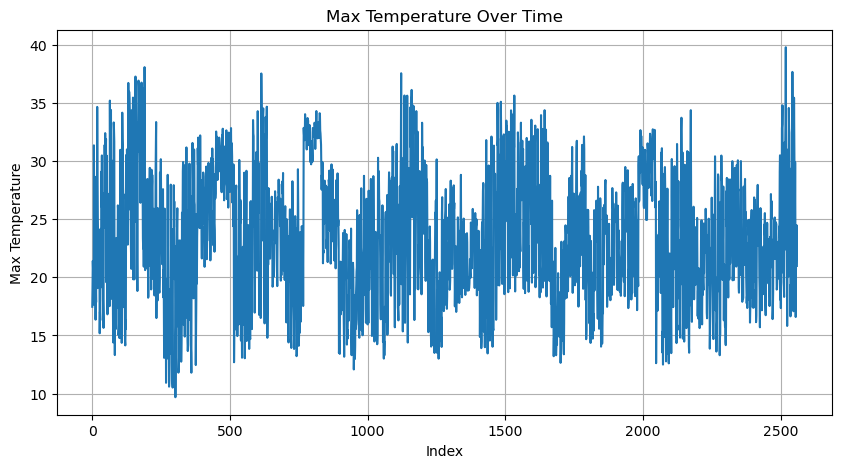

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(samples['MaxTemp'])
plt.title('Max Temperature Over Time')
plt.xlabel('Index')
plt.ylabel('Max Temperature')
plt.grid(True)
plt.show()


In [20]:
print(samples['Location'].value_counts())

Location
Adelaide            64
Albury              64
AliceSprings        64
BadgerysCreek       64
Ballarat            64
Bendigo             64
Brisbane            64
Cairns              64
Canberra            64
Cobar               64
CoffsHarbour        64
Dartmoor            64
Darwin              64
GoldCoast           64
Hobart              64
Melbourne           64
MelbourneAirport    64
Mildura             64
Moree               64
MountGambier        64
NorahHead           64
NorfolkIsland       64
Nuriootpa           64
PearceRAAF          64
Perth               64
PerthAirport        64
Portland            64
Richmond            64
Sale                64
Sydney              64
SydneyAirport       64
Townsville          64
Tuggeranong         64
WaggaWagga          64
Walpole             64
Watsonia            64
Williamtown         64
Witchcliffe         64
Wollongong          64
Woomera             64
Name: count, dtype: int64


In [21]:
samples.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'],
      dtype='object')

## Univariate Forecasting
---

Next, we need to select the features that we are going to use as inputs for our weather forecast. Whether we select a single feature, or multiple features will determine whether the model is a univariate or multivariate LSTM.

Univariate LSTMs process a single time-dependent variable, such as daily stock prices or temperature readings, focusing on temporal patterns within that single feature to predict future values of the same variable. In contrast, multivariate LSTMs handle multiple interrelated variables simultaneously, such as temperature, humidity, wind speed, and pressure for weather forecasting, allowing the model to capture not only temporal dependencies but also complex relationships between different features over time.

To begin with, we will start with a simple, univariate model. We will use the historical (`MaxTemp`) as the time-dependent variable, and predict the maximum temperature for the day (`MaxTemp`). Extract this feature into the corresponding X/y values as we have done in previous practicals.

### Creating Sequences for Forecasting Multiple Data Points
---

We cannot simply feed the input data into the network in its original row-based form as we have done with other network architectures. Since we are predicting the "next" multipe time series value based on previous observations, we need to first transform the data into a "sequence", where each element in the sequence represents the attribute at that given point in time.

This is also known as sequence-to-sequence prediction. Sequence-to-sequence is a more challenging problem, as we have to forecast a greater number of data points with the same amount of input data, compared to predicting one value at a time, where you have another time step worth of features.

To do so, we are going to define a function named `create_sequences()`. This function should take our input data, the target values, and a sequence length as parameters. Our input is going to be of dimension $ N \times T \times F $, and create an output of $ N \times P $, where $ N $ represents the number of samples, $ T $ represents the number of time points to lookback in the past, $ F $ represents the number of features, and $ P $ represents the number of future time points (forecast horizon) that we are predicting.

Note that all sequences are padded to the same length, which ensures that the model can efficiently handle inputs of varying original lenghts while maintaining consistent input dimensions. 